In [19]:
import pandas as pd # For dataframes (tables)
import numpy as np # For numerical operations
import math
import matplotlib.pyplot as plt # For plots
import os # To import external python files
import sys # To import external python files

filename = 'KDDTrain+_20Percent.txt'
print('Ready to read:', filename)

Ready to read: KDDTrain+_20Percent.txt


In [20]:
df = pd.read_csv(filename)
df.head(n=14)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [21]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  str    
 2   service                      25192 non-null  str    
 3   flag                         25192 non-null  str    
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell                 

In [22]:
print ("Values of attack: ",  df['attack'].unique() )
print ("Values of level ",  df['level'].unique() )

Values of attack:  <StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy']
Length: 22, dtype: str
Values of level  [20 15 19 21 18 17 16 12 14 11  2 13 10  9  8  7  3  5  1  6  0  4]


In [23]:
df.shape


(25192, 43)

In [24]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769,19.487695
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333,2.328541
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [25]:
# Distribution of attack types
attack_counts = df['attack'].value_counts()
print("Attack type distribution:")
print(attack_counts)
print(f"\nTotal samples: {len(df)}")
print(f"Normal samples: {(df['attack'] == 'normal').sum()} ({(df['attack'] == 'normal').sum()/len(df)*100:.1f}%)")
print(f"Attack samples: {(df['attack'] != 'normal').sum()} ({(df['attack'] != 'normal').sum()/len(df)*100:.1f}%)")

Attack type distribution:
attack
normal             13449
neptune             8282
ipsweep              710
satan                691
portsweep            587
smurf                529
nmap                 301
back                 196
teardrop             188
warezclient          181
pod                   38
guess_passwd          10
warezmaster            7
buffer_overflow        6
imap                   5
rootkit                4
multihop               2
phf                    2
ftp_write              1
land                   1
loadmodule             1
spy                    1
Name: count, dtype: int64

Total samples: 25192
Normal samples: 13449 (53.4%)
Attack samples: 11743 (46.6%)


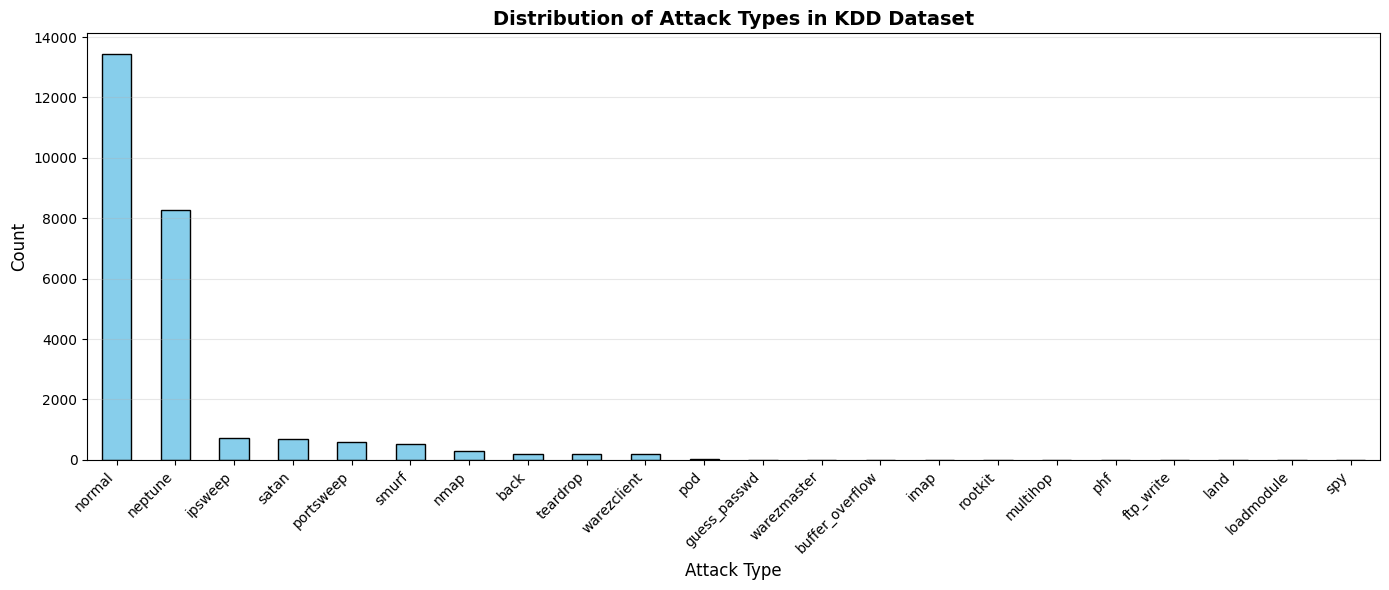

In [26]:
# Visualize attack distribution
plt.figure(figsize=(14, 6))
attack_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Attack Types in KDD Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 features most correlated with attack level:
level                       1.000000
dst_host_srv_count          0.269342
logged_in                   0.266590
dst_host_same_srv_rate      0.124760
dst_host_count              0.030077
dst_host_srv_serror_rate    0.015709
srv_serror_rate             0.012758
serror_rate                 0.008465
dst_host_serror_rate        0.005569
num_access_files           -0.008333
num_root                   -0.010988
Name: level, dtype: float64


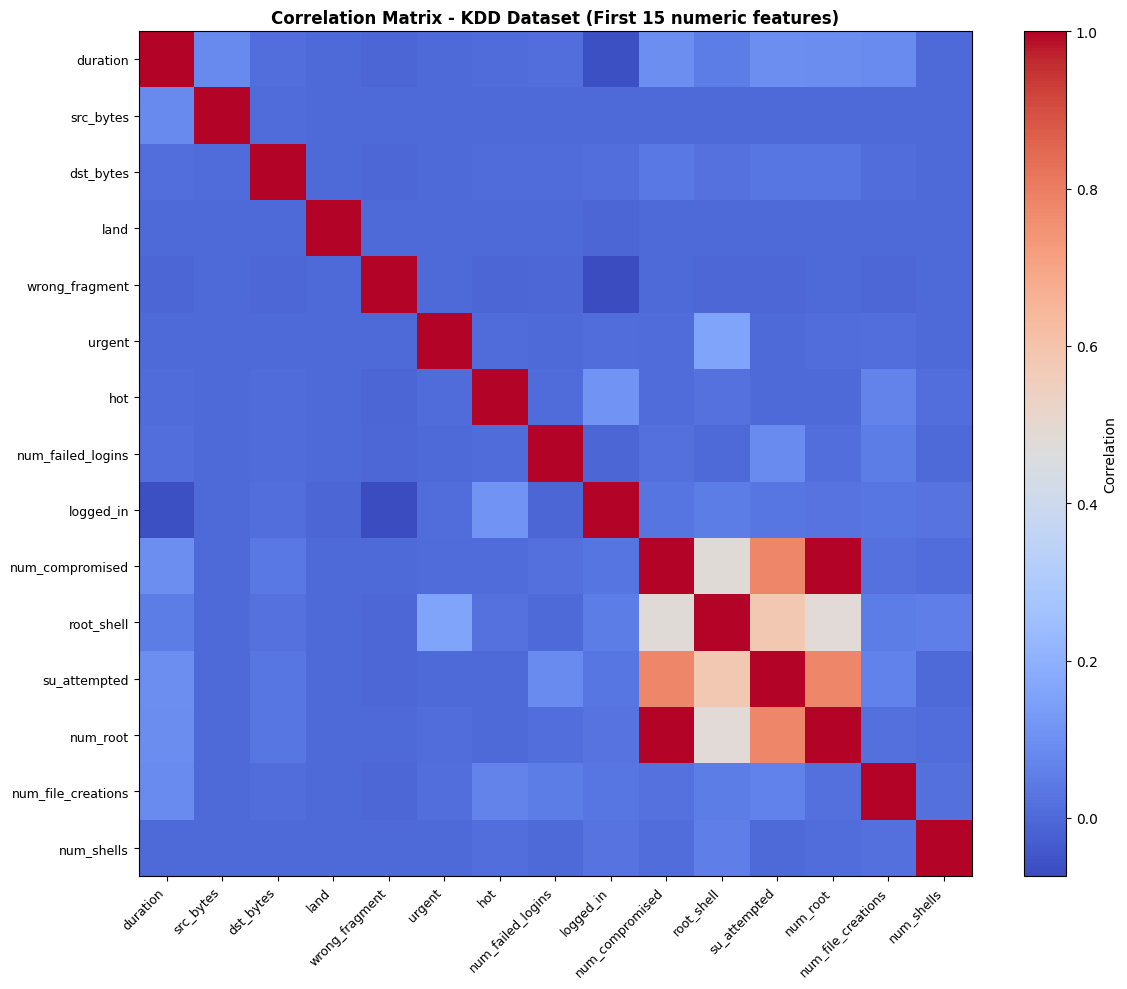

In [27]:
# Correlation matrix - only numeric features
df_numeric = df.select_dtypes(include=[np.number])
correlation_matrix = df_numeric.corr()

# Find highest correlations with 'level' (attack severity indicator)
level_corr = correlation_matrix['level'].sort_values(ascending=False)
print("Top 10 features most correlated with attack level:")
print(level_corr.head(11))  # 11 because 'level' itself is first

# Plot correlation matrix using matplotlib (no seaborn)
plt.figure(figsize=(12, 10))
im = plt.imshow(correlation_matrix.iloc[:15, :15], cmap='coolwarm', aspect='auto')
plt.colorbar(im, label='Correlation')
plt.xticks(range(15), correlation_matrix.columns[:15], rotation=45, ha='right', fontsize=9)
plt.yticks(range(15), correlation_matrix.columns[:15], fontsize=9)
plt.title('Correlation Matrix - KDD Dataset (First 15 numeric features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

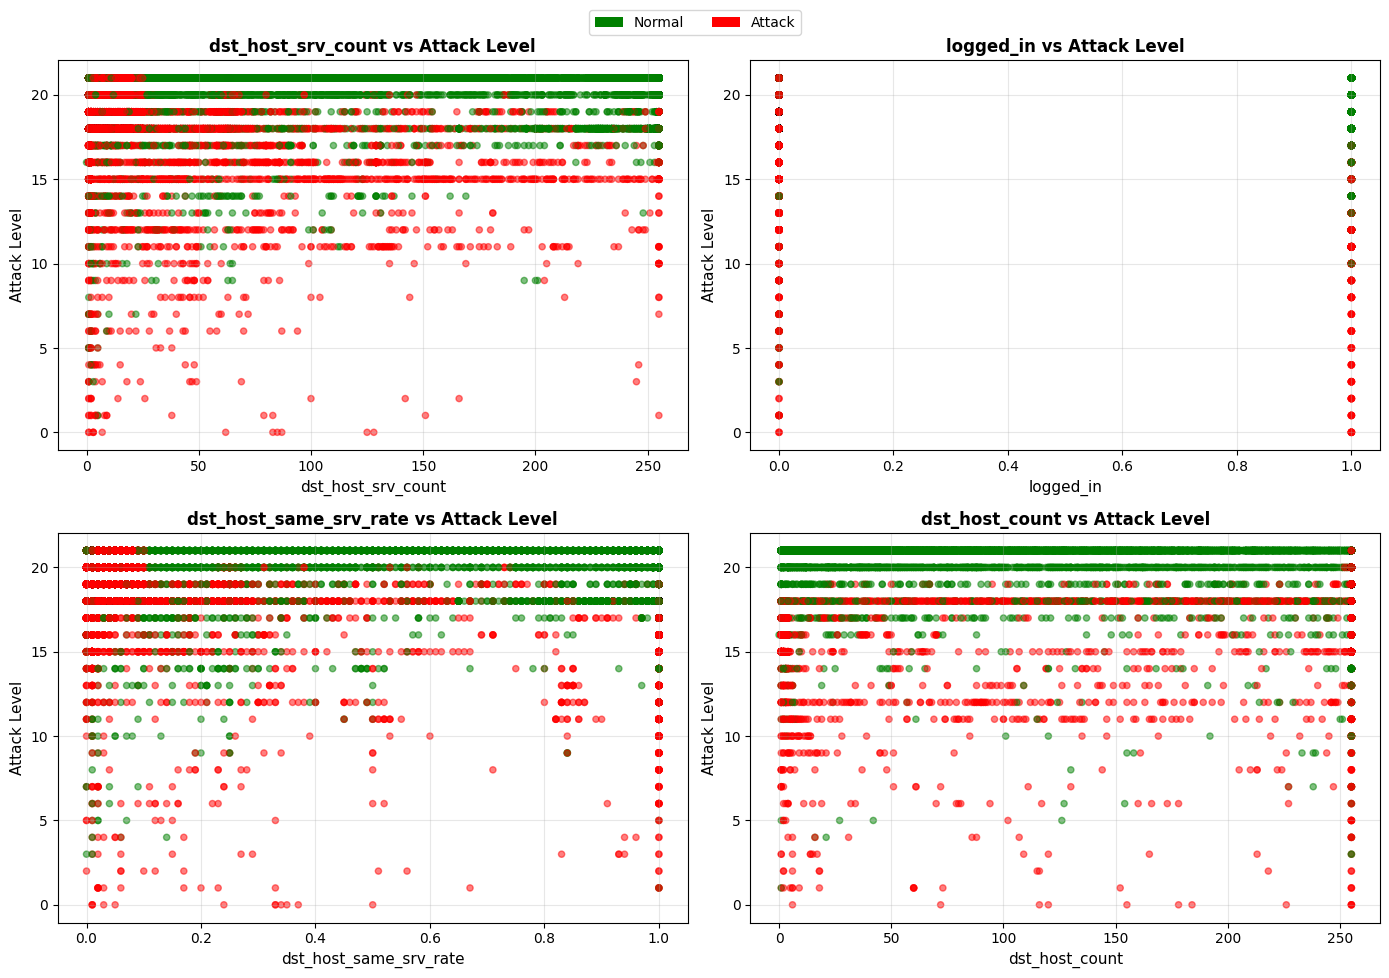

In [28]:
# Scatter plots for most important features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get top 4 most correlated features with level (excluding level itself)
top_features = level_corr[1:5].index.tolist()

for idx, feature in enumerate(top_features):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Color by attack type (normal vs attack)
    colors = ['green' if attack == 'normal' else 'red' for attack in df['attack']]
    ax.scatter(df[feature], df['level'], alpha=0.5, c=colors, s=20)
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Attack Level', fontsize=11)
    ax.set_title(f'{feature} vs Attack Level', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Normal'),
                   Patch(facecolor='red', label='Attack')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.98))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<Axes: >

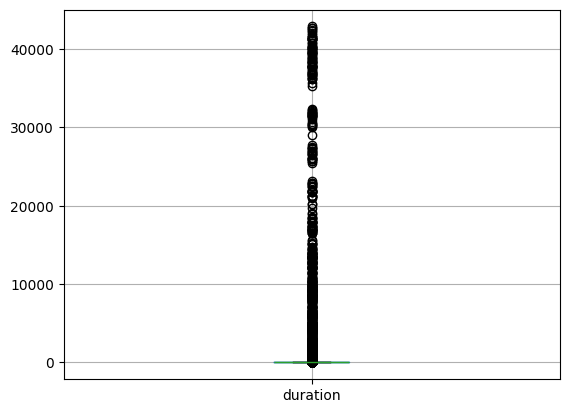

In [29]:
df.boxplot(column=['duration'])

Full Correlation Matrix (all numeric columns):
Total numeric features: 39


                             duration  src_bytes  dst_bytes      land  \
duration                     1.000000   0.084864   0.013258 -0.001012   
src_bytes                    0.084864   1.000000   0.003611 -0.000090   
dst_bytes                    0.013258   0.003611   1.000000 -0.000350   
land                        -0.001012  -0.000090  -0.000350  1.000000   
wrong_fragment              -0.010358  -0.000916  -0.003586 -0.000813   
urgent                      -0.000486  -0.000062   0.000345 -0.000056   
hot                          0.004202   0.000995   0.002539 -0.000819   
num_failed_logins            0.011108  -0.000260   0.005197 -0.000234   
logged_in                   -0.063703  -0.002040   0.012704 -0.007196   
num_compromised              0.095215  -0.000196   0.035852 -0.000195   
root_shell                   0.050547  -0.000383   0.020214 -0.000351   
su_attempted                 0.094243  -0.000267

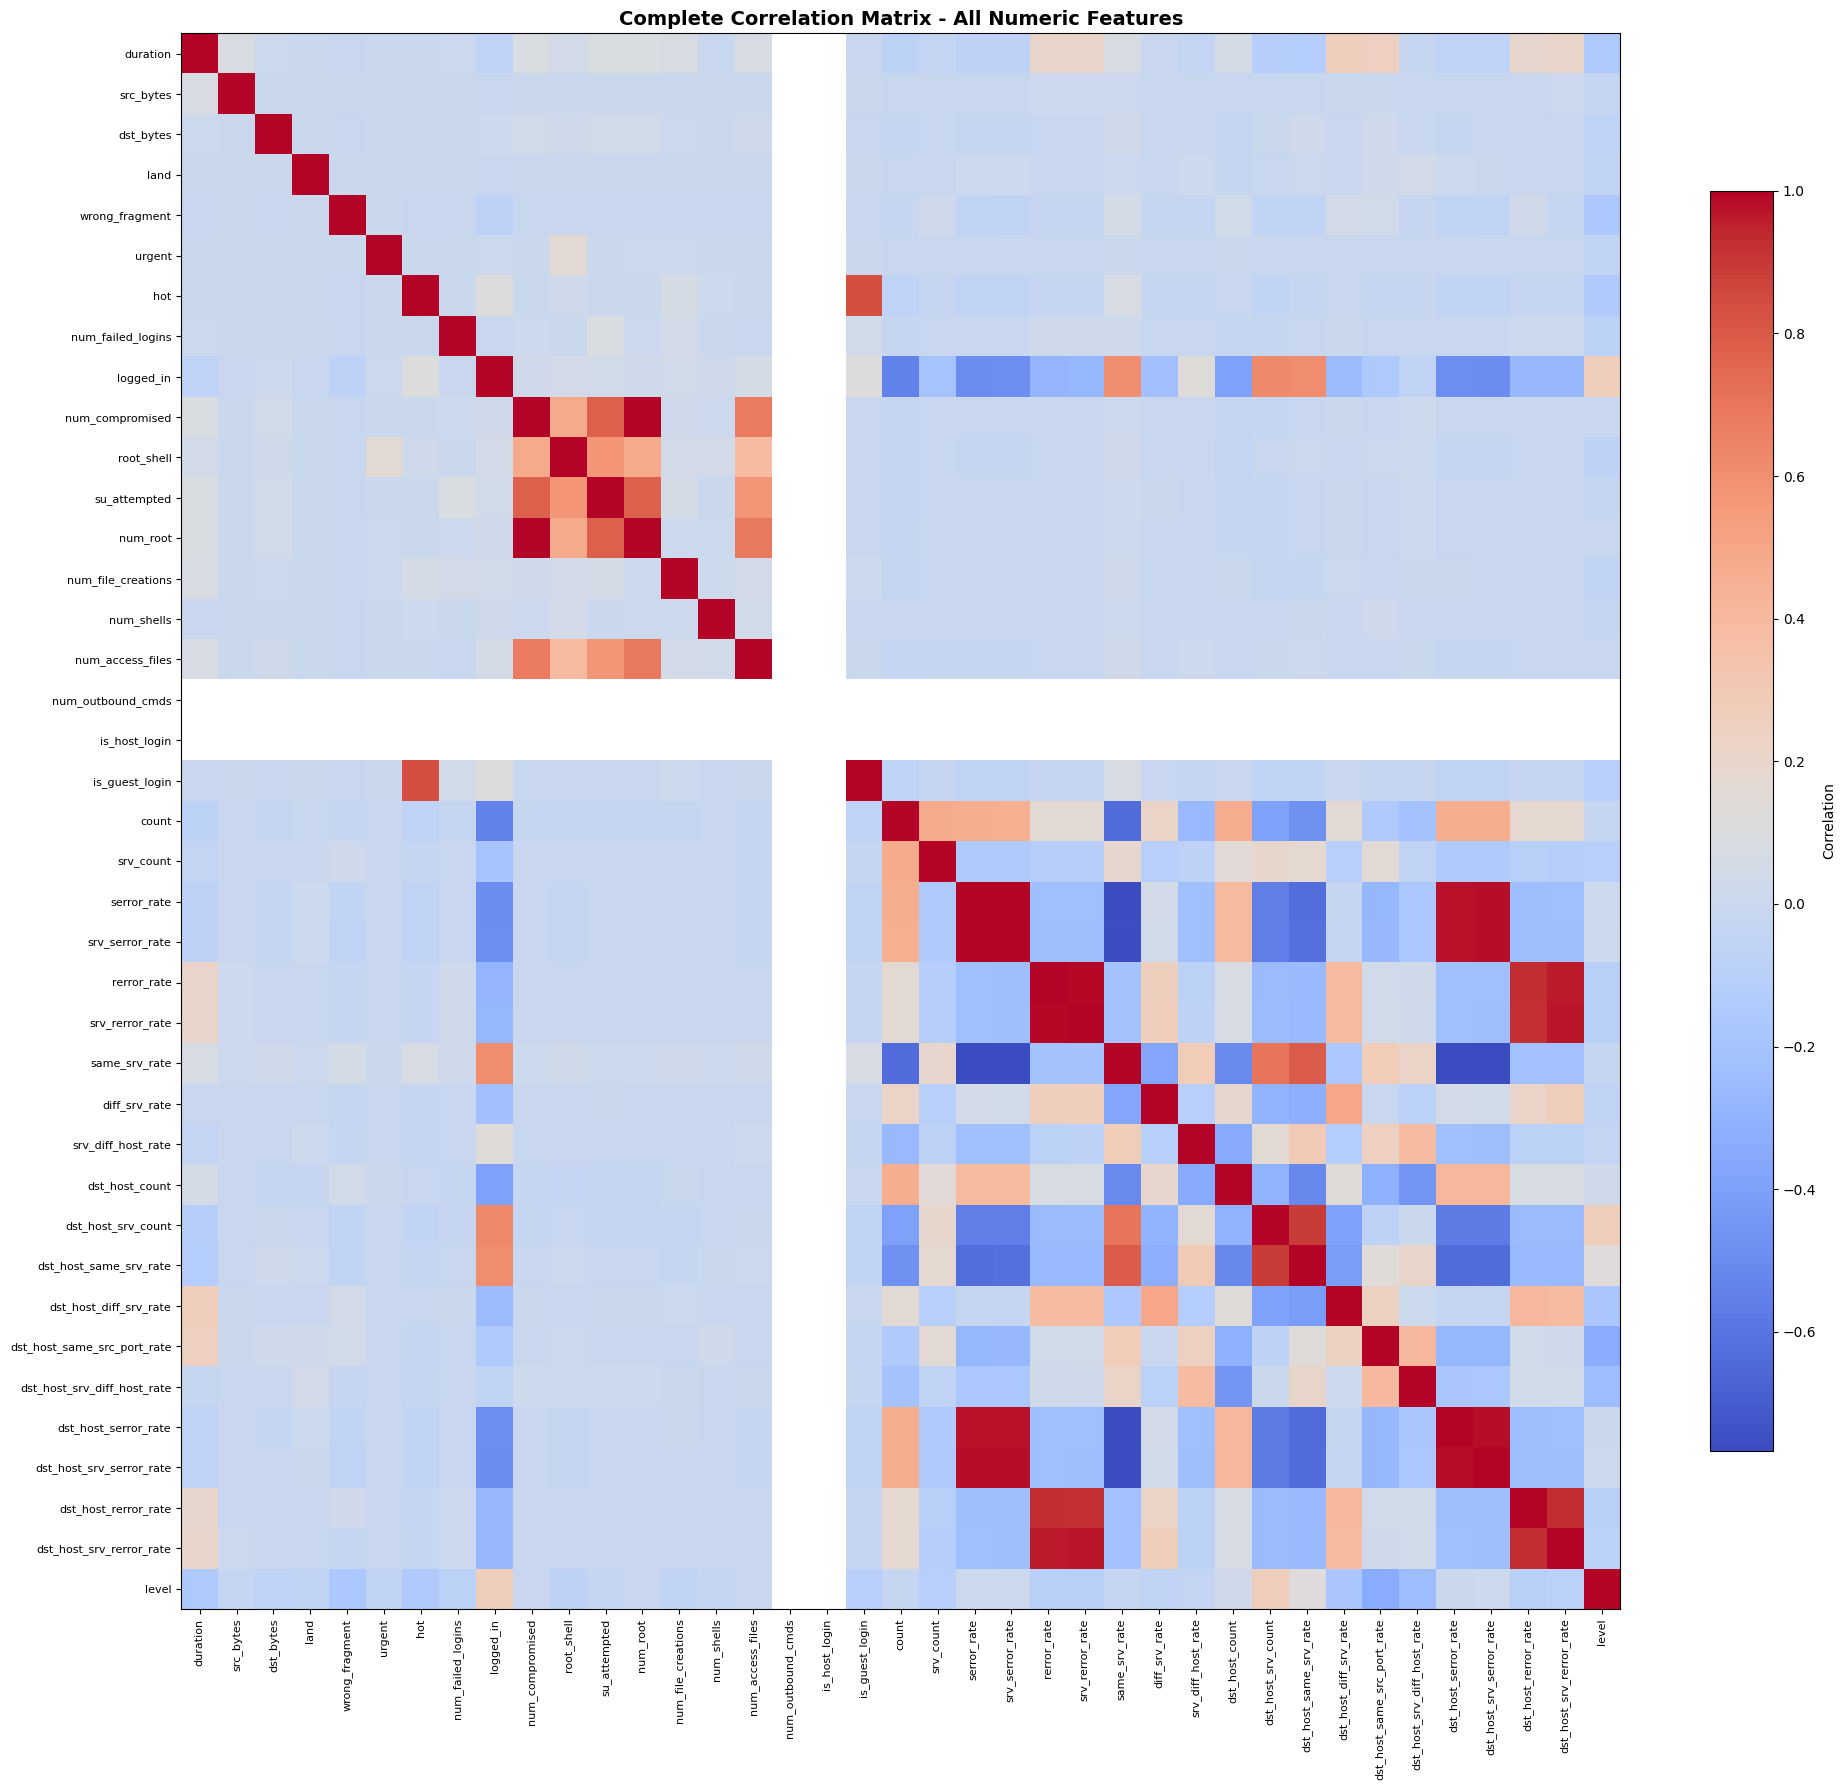

In [31]:
# Full correlation matrix - ALL numeric features
print("Full Correlation Matrix (all numeric columns):")
print(f"Total numeric features: {len(correlation_matrix.columns)}")
print("\n")
print(correlation_matrix)

# Plot FULL correlation matrix as heatmap
plt.figure(figsize=(20, 18))
im = plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(im, label='Correlation', shrink=0.8)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90, fontsize=8)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, fontsize=8)
plt.title('Complete Correlation Matrix - All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()